# Week 3 EDA and Model Implementations

## Project
Token-Efficient Multimodal Reasoning via Scene-to-Structured-Text Compression

## Goals for this notebook
- Load and inspect the GQA dataset subset
- Perform initial EDA with visuals
- Prepare preprocessing steps
- Start baseline and SST model implementation

In [18]:
import sys
import os
import json
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

print('Notebook setup complete')


Notebook setup complete


In [19]:
# Add project root to path


#sys.path.append(os.path.abspath("src"))
sys.path.append(os.path.abspath("../src"))

# Import loader
from dataset.gqa_loader import load_gqa_questions

# Load sample data
file_path = "../data/raw/sample_questions.json"

records = load_gqa_questions(file_path)

print(f"Loaded {len(records)} records")
print(records[0])

Loaded 3 records
{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}}}


In [ ]:
# Convert records to DataFrame for EDA


df = pd.DataFrame(records)

print(df.head())

  question_id image_id                     question answer  \
0          q1     img1       What color is the bus?    red   
1          q2     img2   How many people are there?      3   
2          q3     img3  Is the person near the car?    yes   

                       types  \
0  {'semantic': 'attribute'}   
1      {'semantic': 'count'}   
2   {'semantic': 'relation'}   

                                         full_record  
0  {'imageId': 'img1', 'question': 'What color is...  
1  {'imageId': 'img2', 'question': 'How many peop...  
2  {'imageId': 'img3', 'question': 'Is the person...  


In [7]:
# Extract semantic type from nested dictionary
df["semantic_type"] = df["types"].apply(lambda x: x.get("semantic") if isinstance(x, dict) else None)

print(df[["question", "semantic_type"]])

                      question semantic_type
0       What color is the bus?     attribute
1   How many people are there?         count
2  Is the person near the car?      relation


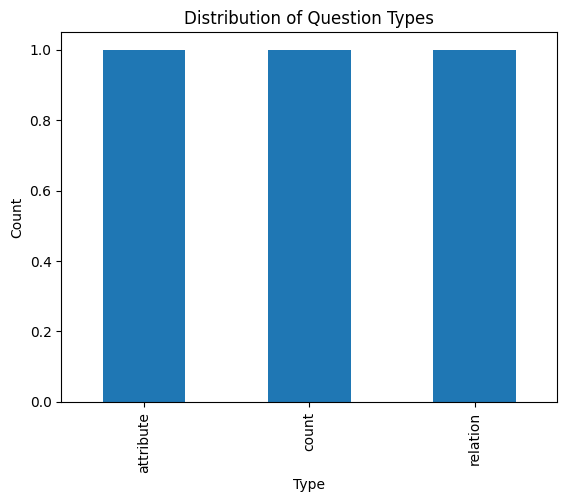

In [ ]:
# Plot distribution of question types


type_counts = df["semantic_type"].value_counts()

plt.figure()
type_counts.plot(kind="bar")

plt.title("Distribution of Question Types")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

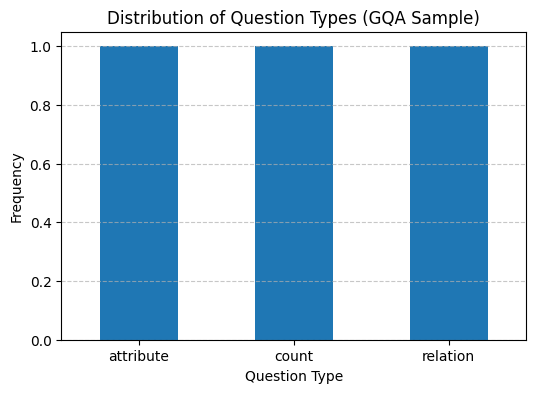

In [ ]:
# Improved visualization for report


type_counts = df["semantic_type"].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind="bar")

plt.title("Distribution of Question Types (GQA Sample)", fontsize=12)
plt.xlabel("Question Type")
plt.ylabel("Frequency")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure for report
plt.savefig("../outputs/eda/question_type_distribution.png")

plt.show()

In [11]:
# Analyze question length
df["question_length"] = df["question"].apply(lambda x: len(x.split()))

print(df[["question", "question_length"]])

                      question  question_length
0       What color is the bus?                5
1   How many people are there?                5
2  Is the person near the car?                6


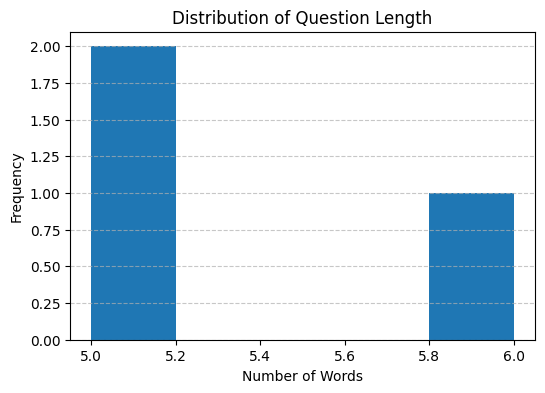

In [ ]:
# Plot question length distribution


plt.figure(figsize=(6,4))
plt.hist(df["question_length"], bins=5)

plt.title("Distribution of Question Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("../outputs/eda/question_length_distribution.png")

plt.show()

In [13]:
# Analyze question length by semantic type
grouped = df.groupby("semantic_type")["question_length"].mean()

print(grouped)

semantic_type
attribute    5.0
count        5.0
relation     6.0
Name: question_length, dtype: float64


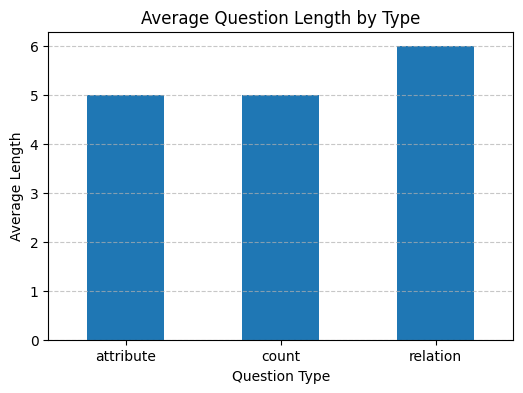

In [ ]:
# Plot average question length per type


plt.figure(figsize=(6,4))
grouped.plot(kind="bar")

plt.title("Average Question Length by Type")
plt.xlabel("Question Type")
plt.ylabel("Average Length")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("../outputs/eda/question_length_by_type.png")

plt.show()

In [33]:
import pandas as pd

raw_data = load_gqa_questions("../data/raw/sample_questions.json")
df = pd.DataFrame(raw_data)

print(df.columns)
print(df.head())

Index(['question_id', 'image_id', 'question', 'answer', 'types',
       'full_record'],
      dtype='str')
  question_id image_id                     question answer  \
0          q1     img1       What color is the bus?    red   
1          q2     img2   How many people are there?      3   
2          q3     img3  Is the person near the car?    yes   

                       types  \
0  {'semantic': 'attribute'}   
1      {'semantic': 'count'}   
2   {'semantic': 'relation'}   

                                         full_record  
0  {'imageId': 'img1', 'question': 'What color is...  
1  {'imageId': 'img2', 'question': 'How many peop...  
2  {'imageId': 'img3', 'question': 'Is the person...  


In [34]:
# Basic text preprocessing

# Convert questions to lowercase
df["question_clean"] = df["question"].str.lower()

# Remove punctuation


def clean_text(text):
    text = re.sub(r"[^\w\s]", "", text)
    return text

df["question_clean"] = df["question_clean"].apply(clean_text)

print(df[["question", "question_clean"]])

                      question              question_clean
0       What color is the bus?       what color is the bus
1   How many people are there?   how many people are there
2  Is the person near the car?  is the person near the car


In [36]:
df["question_clean"] = df["question"].str.lower().str.strip()
print(df[["question", "question_clean"]].head())

                      question               question_clean
0       What color is the bus?       what color is the bus?
1   How many people are there?   how many people are there?
2  Is the person near the car?  is the person near the car?


In [37]:
# Basic text preprocessing
import re
# Convert questions to lowercase
df["question_clean"] = df["question"].str.lower()

# Remove punctuation


def clean_text(text):
    text = re.sub(r"[^\w\s]", "", text)
    return text

df["question_clean"] = df["question_clean"].apply(clean_text)

print(df[["question", "question_clean"]])

                      question              question_clean
0       What color is the bus?       what color is the bus
1   How many people are there?   how many people are there
2  Is the person near the car?  is the person near the car


In [38]:
# Prepare inputs for modeling

X = df["question_clean"]   # input
y = df["answer"]           # target

print("Sample input:", X.iloc[0])
print("Sample label:", y.iloc[0])

Sample input: what color is the bus
Sample label: red


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Make sure cleaned text exists
if "question_clean" not in df.columns:
    df["question_clean"] = df["question"].str.lower().str.strip()

# Convert text to numerical features
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(df["question_clean"])

y = df["answer"]

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_vec, y)

# Predict on the same data (sanity check only)
y_pred = model.predict(X_vec)

# Accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Baseline Logistic Regression Accuracy: {accuracy:.2f}")

# Show predictions
for i in range(X_vec.shape[0]):
    print(f"Q: {df['question_clean'].iloc[i]}")
    print(f"Actual: {y.iloc[i]} | Predicted: {y_pred[i]}")
    print("-" * 40)

Baseline Logistic Regression Accuracy: 1.00
Q: what color is the bus
Actual: red | Predicted: red
----------------------------------------
Q: how many people are there
Actual: 3 | Predicted: 3
----------------------------------------
Q: is the person near the car
Actual: yes | Predicted: yes
----------------------------------------


In [40]:
from sklearn.metrics import accuracy_score

# Predict on training data (for now)
y_pred = model.predict(X_vec)

# Calculate accuracy
accuracy = accuracy_score(y, y_pred)

print(f"Baseline Logistic Regression Accuracy: {accuracy:.2f}")

Baseline Logistic Regression Accuracy: 1.00


In [29]:
# Test the SST builder

from serializer.sst_builder import build_sst, sst_to_prompt

sample_sst = build_sst(
    objects=["bus", "person", "stop_sign"],
    counts={"person": 3},
    attributes=["bus: red"],
    relations=["person near bus", "stop_sign right of bus"],
    text=["STOP"]
)

print(sample_sst)
print()
print(sst_to_prompt(sample_sst))

{'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}

Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP


In [2]:
import json

with open("../data/processed/sample_questions_with_sst.json", "r") as f:
    records = json.load(f)

print(type(records))
print(len(records))
print(records["q1"])

<class 'dict'>
3
{'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [3]:
sample = records["q1"]
print(sample["question"])
print(sample["answer"])
print(sample["types"]["semantic"])
print(sample["sst"])

What color is the bus?
red
attribute
{'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}


In [5]:
import sys
import os

project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

print("Project root:", project_root)
print("Added src path:", src_path)

Project root: /Users/alisha/Documents/CSE427_SST_Project
Added src path: /Users/alisha/Documents/CSE427_SST_Project/src


In [6]:
from dataset.gqa_loader import load_gqa_questions

data_with_sst = load_gqa_questions("../data/processed/sample_questions_with_sst.json")
print(data_with_sst[0])

{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [7]:
from serializer.sst_builder import sst_to_prompt

sample = data_with_sst[0]

prompt_text = sst_to_prompt(sample["sst"])

print("QUESTION:")
print(sample["question"])

print("\nGROUND TRUTH ANSWER:")
print(sample["answer"])

print("\nSST PROMPT:")
print(prompt_text)

QUESTION:
What color is the bus?

GROUND TRUTH ANSWER:
red

SST PROMPT:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP


In [8]:
for i, sample in enumerate(data_with_sst):
    print(f"\n--- Sample {i+1} ---")
    print("Question:", sample["question"])
    print("Semantic type:", sample["types"]["semantic"])
    print(sst_to_prompt(sample["sst"]))


--- Sample 1 ---
Question: What color is the bus?
Semantic type: attribute
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

--- Sample 2 ---
Question: How many people are there?
Semantic type: count
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

--- Sample 3 ---
Question: Is the person near the car?
Semantic type: relation
Scene-to-Structured-Text Representation:
Objects: person, car, tree
Counts: person: 1, car: 1
Attributes: car: blue
Relations: person near car, tree left of car
Text: None


In [9]:
from filtering.question_aware_filter import filter_sst_by_question_type
from serializer.sst_builder import sst_to_prompt

sample = data_with_sst[0]

semantic_type = sample["types"]["semantic"]

filtered_sst = filter_sst_by_question_type(sample["sst"], semantic_type)

print("QUESTION TYPE:", semantic_type)

print("\nFULL SST:")
print(sst_to_prompt(sample["sst"]))

print("\nFILTERED SST:")
print(sst_to_prompt(filtered_sst))

QUESTION TYPE: attribute

FULL SST:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

FILTERED SST:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: None
Attributes: bus: red
Relations: None
Text: STOP


In [10]:
def mock_reasoning(sample):
    """
    Simple rule-based reasoning to simulate LLM behavior.
    This is NOT the final model — just for pipeline validation.
    """

    sst = sample["sst"]
    question = sample["question"].lower()

    # COUNT
    if "how many" in question:
        if sst["counts"]:
            return sst["counts"][0].split(":")[-1].strip()

    # ATTRIBUTE (color)
    if "color" in question:
        if sst["attributes"]:
            return sst["attributes"][0].split(":")[-1].strip()

    # RELATION (yes/no)
    if "near" in question or "left" in question or "right" in question:
        if sst["relations"]:
            return "yes"

    return "unknown"

In [11]:
for sample in data_with_sst:
    pred = mock_reasoning(sample)

    print("\nQUESTION:", sample["question"])
    print("GT:", sample["answer"])
    print("PRED:", pred)


QUESTION: What color is the bus?
GT: red
PRED: red

QUESTION: How many people are there?
GT: 3
PRED: 3

QUESTION: Is the person near the car?
GT: yes
PRED: yes


In [12]:
def evaluate_pipeline(data):
    results = []

    for sample in data:
        question = sample["question"]
        answer = sample["answer"]
        semantic_type = sample["types"]["semantic"]

        # FULL SST
        full_prompt = sst_to_prompt(sample["sst"])
        full_pred = mock_reasoning(sample)
        full_tokens = len(full_prompt.split())
        full_correct = (full_pred == answer)

        # FILTERED SST
        filtered_sst = filter_sst_by_question_type(sample["sst"], semantic_type)
        filtered_prompt = sst_to_prompt(filtered_sst)

        # simulate reasoning using filtered SST
        sample_filtered = sample.copy()
        sample_filtered["sst"] = filtered_sst

        filtered_pred = mock_reasoning(sample_filtered)
        filtered_tokens = len(filtered_prompt.split())
        filtered_correct = (filtered_pred == answer)

        results.append({
            "question": question,
            "full_tokens": full_tokens,
            "filtered_tokens": filtered_tokens,
            "full_correct": full_correct,
            "filtered_correct": filtered_correct
        })

    return results

In [13]:
results = evaluate_pipeline(data_with_sst)

for r in results:
    print(r)

{'question': 'What color is the bus?', 'full_tokens': 22, 'filtered_tokens': 15, 'full_correct': True, 'filtered_correct': True}
{'question': 'How many people are there?', 'full_tokens': 22, 'filtered_tokens': 15, 'full_correct': True, 'filtered_correct': True}
{'question': 'Is the person near the car?', 'full_tokens': 24, 'filtered_tokens': 20, 'full_correct': True, 'filtered_correct': True}


In [14]:
import numpy as np

full_acc = np.mean([r["full_correct"] for r in results])
filtered_acc = np.mean([r["filtered_correct"] for r in results])

avg_full_tokens = np.mean([r["full_tokens"] for r in results])
avg_filtered_tokens = np.mean([r["filtered_tokens"] for r in results])

print("FULL ACCURACY:", full_acc)
print("FILTERED ACCURACY:", filtered_acc)

print("\nAVG TOKENS (FULL):", avg_full_tokens)
print("AVG TOKENS (FILTERED):", avg_filtered_tokens)

FULL ACCURACY: 1.0
FILTERED ACCURACY: 1.0

AVG TOKENS (FULL): 22.666666666666668
AVG TOKENS (FILTERED): 16.666666666666668


In [15]:
import pandas as pd

df = pd.DataFrame(results)
df

,question,full_tokens,filtered_tokens,full_correct,filtered_correct
0,What color is the bus?,22,15,True,True
1,How many people are there?,22,15,True,True
2,Is the person near the car?,24,20,True,True


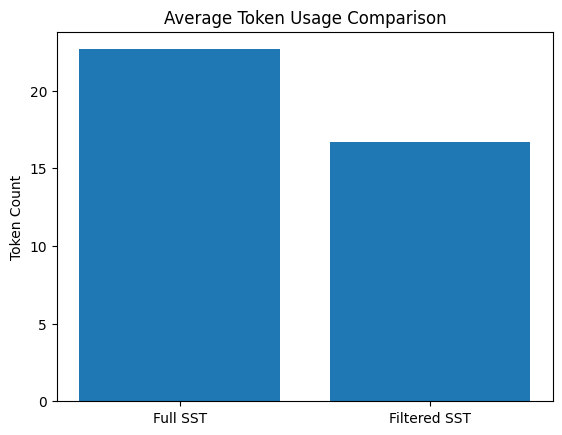

In [16]:
import matplotlib.pyplot as plt

labels = ["Full SST", "Filtered SST"]
tokens = [avg_full_tokens, avg_filtered_tokens]

plt.bar(labels, tokens)
plt.title("Average Token Usage Comparison")
plt.ylabel("Token Count")
plt.show()